# 課題6: ディープラーニングのモデルを構築しよう

今回の課題では手書き数字の認識を、CNNを用いて行います。ただし本課題では、レッスン本編で用いたscikit-learnのものではなく、Kerasのデータセットに含まれている、より大きいサイズの手書き数字データで課題を進めていただきます。

下記にKerasから手書き数字のデータセットをダウンロードするコードが記載されています。このデータを用いてディープラーニングのモデルを構築してください。

今までのレッスンで学んだ内容を踏まえ、各セルにコードを埋めていってください。

（※`変更しないでください`と書かれたセルには、コードの追記変更をしないでください）

## 1. ライブラリのimport

In [1]:
# （変更しないでください）

# 必要なライブラリのimport
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# TensorFlow
import tensorflow as tf

# データの分割
from sklearn.model_selection import train_test_split

# DataFrameですべての列を表示する設定
pd.options.display.max_columns = None

E:\学習\202512_TeckAcademy_AI\aidev\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## 2. データの読み込み

Kerasのデータセットは、あらかじめTraining setとTest setに分けられています。戻り値はタプルで取得できます。

In [2]:
# Kerasに添付されている手書き数字のデータセットをダウンロードして読み込む
# （変更しないでください）
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## 3. データの確認

In [3]:
# X_train, Y_train, X_test, Y_testの形状を確認
print("Y_train=", Y_train.shape, ", X_train=", X_train.shape)
print("Y_test=", Y_test.shape, ", X_test=", X_test.shape)

Y_train= (60000,) , X_train= (60000, 28, 28)
Y_test= (10000,) , X_test= (10000, 28, 28)


In [4]:
# X_trainの先頭1行を表示
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [5]:
# Y_trainの先頭1行を表示
Y_train[0]

np.uint8(5)

データセットを可視化して表示します。

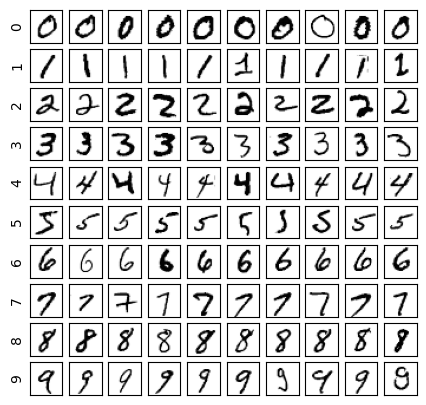

In [6]:
# （変更しないでください）

# 「数字:空のリスト」の辞書を作成する
images = {label: [] for label in range(0,10)}

# 総イメージ数
image_count = 0

# それぞれの数字のリストに、説明変数をappendしていく
for i in range(0, len(X_train)):
    if len(images[Y_train[i]]) < 10:
        images[Y_train[i]].append(X_train[i])
        image_count += 1
        if image_count == 100:
            break

# 10行10列にグラフを分割
fig, ax = plt.subplots(10, 10, figsize=(5, 5))

for i in range(10):
    # ラベル
    ax[i, 0].set_ylabel(i)

    for j in range(10):
        # 行=i、列=jの位置に画像を描画する
        ax[i, j].imshow(images[i][j].reshape(28, 28), cmap='Greys')

        # 目盛を表示しない設定
        ax[i, j].tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)

plt.show()

## 4. データの前処理

In [7]:
# len関数を使い、X_trainを(X_trainの長さ, 28, 28, 1)にreshapeしてX_train2に代入
X_train2 = X_train.reshape(len(X_train), 28, 28, 1)

# len関数を使い、X_testを(X_testの長さ, 28, 28, 1)にreshapeしてX_test2に代入
X_test2 = X_test.reshape(len(X_test), 28, 28, 1)

In [8]:
# to_categoricalを使い、Y_trainをカテゴリー変数に展開してY_train2に代入
Y_train2 = tf.keras.utils.to_categorical(Y_train)

# to_categoricalを使い、Y_testをカテゴリー変数に展開してY_test2に代入
Y_test2 = tf.keras.utils.to_categorical(Y_test)

In [9]:
# X_train2, Y_train2, X_test2, Y_test2の形状を確認
print("Y_train2=", Y_train2.shape, ", X_train2=", X_train2.shape)
print("Y_test2=", Y_test2.shape, ", X_test2=", X_test2.shape)

Y_train2= (60000, 10) , X_train2= (60000, 28, 28, 1)
Y_test2= (10000, 10) , X_test2= (10000, 28, 28, 1)


In [10]:
# train_test_splitを使い、学習データと検証データに7:3（検証データが3割）で分割する
# （詳細：データ(X_train2、Y_train2)を「X_train2, X_valid2, Y_train2, Y_valid2」に分割）
X_train2, X_valid2, Y_train2, Y_valid2 = train_test_split(
  X_train2, Y_train2,
  test_size = 0.3, random_state = 0
)

In [11]:
# X_train2, Y_train2, X_valid2, Y_valid2, X_test2, Y_test2の形状を確認
print("Y_train2=", Y_train2.shape, ", X_train2=", X_train2.shape)
print("Y_valid2=", Y_valid2.shape, ", X_valid2=", X_valid2.shape)
print("Y_test2=", Y_test2.shape, ", X_test2=", X_test2.shape)

Y_train2= (42000, 10) , X_train2= (42000, 28, 28, 1)
Y_valid2= (18000, 10) , X_valid2= (18000, 28, 28, 1)
Y_test2= (10000, 10) , X_test2= (10000, 28, 28, 1)


## 5. モデルの構築

Kerasを使ってモデルを構築してみましょう。以下を条件とします：

- CNN(Conv2D)を使うこと
- 正解率(accuracy)が50%以上であること

場合によっては、学習にものすごく時間がかかる場合もあります。適宜、パラメータ数を調整して行なってください。

In [12]:
# （モデルの初期化から構築までのコードを、このセル以下に記述してください）

# モデルの初期化
model = tf.keras.Sequential([
  # 入力層
  tf.keras.Input(shape = (28, 28, 1)),
  tf.keras.layers.Conv2D(
    32,
    kernel_size = 3,
    padding = "same",
    strides = 1,
    activation = 'relu'
  ),
  tf.keras.layers.Flatten(),
  
  # 隠れ層
  tf.keras.layers.Dense(16, activation = 'relu'),
  
  # 出力層
  tf.keras.layers.Dense(10, activation = 'softmax')
])

# モデルの構築
model.compile(
  optimizer = "rmsprop",
  loss = "categorical_crossentropy",
  metrics = ['accuracy']
)

In [13]:
# モデルの構造を表示
model.summary()

Model: "sequential"
┌─────────────────────┬────────────────┬──────────┐
│ Layer (type)        │ Output Shape   │  Param # │
├─────────────────────┼────────────────┼──────────┤
│ conv2d (Conv2D)     │ (None, 28, 28, │      320 │
│                     │ 32)            │          │
├─────────────────────┼────────────────┼──────────┤
│ flatten (Flatten)   │ (None, 25088)  │        0 │
├─────────────────────┼────────────────┼──────────┤
│ dense (Dense)       │ (None, 16)     │  401,424 │
├─────────────────────┼────────────────┼──────────┤
│ dense_1 (Dense)     │ (None, 10)     │      170 │
└─────────────────────┴────────────────┴──────────┘
 Total params: 401,914 (1.53 MB)
 Trainable params: 401,914 (1.53 MB)
 Non-trainable params: 0 (0.00 B)


In [14]:
%%time
# 学習の実施(ものすごく時間がかかる場合もあります)
log = model.fit(
    X_train2, Y_train2,
    epochs = 5000,
    batch_size = 32,
    verbose = True,
    callbacks = [tf.keras.callbacks.EarlyStopping(
      monitor = 'val_loss',
      min_delta = 0,
      patience = 100,
      verbose = 1
    )],
    validation_data = (X_valid2, Y_valid2)
)

Epoch 1/5000
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5605 - loss: 1.4542 - val_accuracy: 0.9349 - val_loss: 0.2308
Epoch 2/5000
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9574 - loss: 0.1482 - val_accuracy: 0.9625 - val_loss: 0.1292
Epoch 3/5000
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9760 - loss: 0.0852 - val_accuracy: 0.9683 - val_loss: 0.1120
Epoch 4/5000
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9837 - loss: 0.0584 - val_accuracy: 0.9607 - val_loss: 0.1424
Epoch 5/5000
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9883 - loss: 0.0433 - val_accuracy: 0.9678 - val_loss: 0.1368
Epoch 6/5000
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9919 - loss: 0.0319 - val_accuracy: 0.9629 - val_loss: 0.1843
Epoch 7/5000
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9935 - loss: 0.0238 - val_accuracy: 0.9681 - val_loss: 0.1957
Epoch 8/5000
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9950 -

Text(0, 0.5, 'crossentropy')

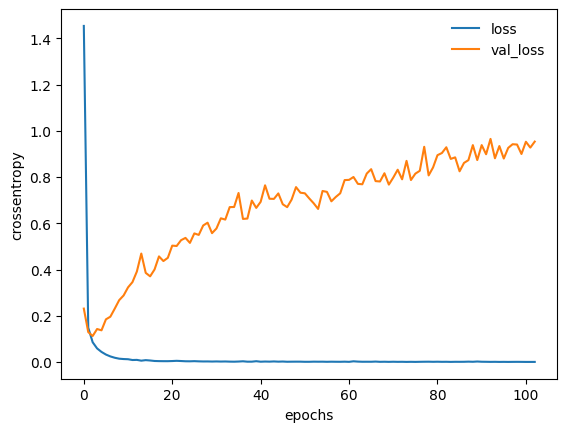

In [15]:
# 学習過程をグラフ表示
plt.plot(log.history['loss'], label = 'loss')
plt.plot(log.history['val_loss'], label = 'val_loss')
plt.legend(frameon = False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

In [16]:
# predictを使い、X_test2をもとに予測した結果を、
# カテゴリー変数へ復元してY_pred2に代入
Y_pred = np.argmax(model.predict(X_test2), axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step


In [17]:
# Y_test2もカテゴリー変数へ復元して、Y_test2_ に代入
Y_test_ = np.argmax(Y_test2, axis = 1)

In [19]:
# classification_reportを使い、モデルの評価を実施
from sklearn.metrics import classification_report
print(classification_report(Y_test_, Y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.97      0.99      0.98      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.97      0.97       892
           6       0.98      0.97      0.97       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

